In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
sys.path.append(str(project_root / "src"))

from pangya_physics import (
    CLUBS,
    Ball,
    Wind,
    PangyaSimulator,
    Vector3D,
)

In [2]:
club = CLUBS["1W"]

power_percent = 0.70

initial_power = club.power_base * power_percent

angle = club.degree_rad()

velocity_y = initial_power * __import__("math").sin(angle)
velocity_z = initial_power * __import__("math").cos(angle)

print(f"Velocity Y: {velocity_y:.2f}")
print(f"Velocity Z: {velocity_z:.2f}")

Velocity Y: 27.96
Velocity Z: 158.55


In [3]:
def simulate_fixed_shot(
    wind_speed: float,
    wind_degree: float,
    max_steps: int = 500,
):
    ball = Ball(
        velocity=Vector3D(
            0.0,
            velocity_y,
            velocity_z,
        )
    )

    wind = Wind(
        speed=wind_speed,
        degree=wind_degree,
    )

    simulator = PangyaSimulator(
        ball=ball,
        club=club,
        wind=wind,
    )

    for _ in range(max_steps):
        simulator.step()

        if simulator.ball.position.y < 0 and simulator.ball.count > 10:
            break

    return {
        "distance": simulator.ball.position.z,
        "max_height": simulator.ball.max_height,
        "steps": simulator.ball.count,
        "desvio": simulator.ball.position.x,
    }

In [4]:
wind_speeds = [0, 2, 4, 6, 8, 10]

favor_results = []

for speed in wind_speeds:

    result = simulate_fixed_shot(
        wind_speed=speed,
        wind_degree=0,
    )

    favor_results.append({
        "Vento": speed,
        "Distância": round(result["distance"], 2),
        "Altura Máxima": round(result["max_height"], 2),
        "Desvio": round(result["desvio"], 4),
        "Passos": result["steps"],
    })

df_favor = pd.DataFrame(favor_results)

df_favor

,Vento,Distância,Altura Máxima,Desvio,Passos
0,0,198.18,9.67,0.0,75
1,2,198.99,9.67,0.0,75
2,4,199.79,9.67,0.0,75
3,6,200.58,9.66,0.0,75
4,8,201.38,9.66,0.0,75
5,10,202.18,9.66,0.0,75


In [5]:
contra_results = []

for speed in wind_speeds:

    result = simulate_fixed_shot(
        wind_speed=speed,
        wind_degree=180,
    )

    contra_results.append({
        "Vento": speed,
        "Distância": round(result["distance"], 2),
        "Altura Máxima": round(result["max_height"], 2),
        "Desvio": round(result["desvio"], 4),
        "Passos": result["steps"],
    })

df_contra = pd.DataFrame(contra_results)

df_contra

,Vento,Distância,Altura Máxima,Desvio,Passos
0,0,198.18,9.67,0.0,75
1,2,197.38,9.67,-0.0,75
2,4,196.58,9.67,-0.0,75
3,6,195.78,9.67,-0.0,75
4,8,194.97,9.67,-0.0,75
5,10,194.17,9.67,-0.0,75


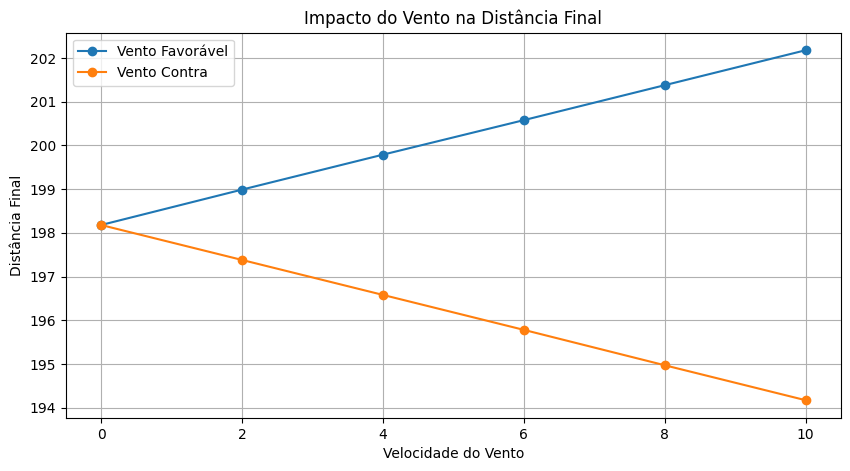

In [6]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_favor["Vento"],
    df_favor["Distância"],
    marker="o",
    label="Vento Favorável",
)

plt.plot(
    df_contra["Vento"],
    df_contra["Distância"],
    marker="o",
    label="Vento Contra",
)

plt.xlabel("Velocidade do Vento")
plt.ylabel("Distância Final")
plt.title("Impacto do Vento na Distância Final")

plt.grid(True)
plt.legend()

plt.show()

In [7]:
base_distance = df_favor.iloc[0]["Distância"]

analysis = []

for _, row in df_favor.iterrows():

    analysis.append({
        "Vento": row["Vento"],
        "Delta Distância": round(
            row["Distância"] - base_distance,
            2,
        ),
    })

pd.DataFrame(analysis)

,Vento,Delta Distância
0,0.0,0.00
1,2.0,0.81
2,4.0,1.61
3,6.0,2.40
4,8.0,3.20
5,10.0,4.00
